# Phase 2: Spatial EDA - METR-LA Network Analysis

Comprehensive spatial analysis of the 207-sensor LA freeway network.

**Objectives:**
1. Visualize sensor network structure and geography
2. Analyze spatial clustering and connectivity patterns
3. Distance-based correlation analysis
4. Geographic heatmaps (mean speed, volatility)
5. Identify spatial communities

**Key Files:**
- sensor_coordinates.npy: (207, 4) - index, sensor_id, lat, lon
- sensor_distances.csv: 295,374 distance pairs
- adjacency_distance.npy: Binary adjacency (5km threshold)
- adjacency_normalized.npy: Normalized spectral adjacency
- spatial_moving_average.npy: (34272, 207, 6)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from scipy.spatial.distance import cdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import networkx as nx
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Paths relative to notebook location (goes up from notebooks/ to AIML_Traffic_Flow_Prediction/)
BASE_DIR = Path.cwd().parent  # From notebooks/ to AIML_Traffic_Flow_Prediction/
RESULTS_DIR = BASE_DIR / 'results'
DATA_DIR = BASE_DIR / 'data' / 'processed'

# Create results directory if it doesn't exist
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Libraries imported and directories ready")
print(f"  Data: {DATA_DIR}")
print(f"  Results: {RESULTS_DIR}")

✓ Libraries imported and directories ready
  Data: c:\Users\LOQ 15IRX9\Downloads\DL_Project_2\AIML_Traffic_Flow_Prediction\data\processed
  Results: c:\Users\LOQ 15IRX9\Downloads\DL_Project_2\AIML_Traffic_Flow_Prediction\results


## Section 1: Load Spatial Data

In [21]:
# Load unified dataset
coordinates = np.load(DATA_DIR / 'sensor_coordinates.npy')
speed_data = np.load(DATA_DIR / 'speed_data.npy')
distances_df = pd.read_csv(DATA_DIR / 'sensor_distances.csv')
adjacency_dist = np.load(DATA_DIR / 'adjacency_distance.npy')
adjacency_norm = np.load(DATA_DIR / 'adjacency_normalized.npy')
spatial_ma = np.load(DATA_DIR / 'spatial_moving_average.npy')

with open(DATA_DIR / 'sensor_id_mappings.json', 'r') as f:
    id_mapping = json.load(f)

# Extract components
n_sensors = coordinates.shape[0]
indices = coordinates[:, 0].astype(int)
sensor_ids = coordinates[:, 1].astype(int)
latitudes = coordinates[:, 2]
longitudes = coordinates[:, 3]

print(f"✓ Spatial data loaded:")
print(f"  Sensors: {n_sensors}")
print(f"  Coordinates: {coordinates.shape}")
print(f"  Speed data: {speed_data.shape}")
print(f"  Spatial MA: {spatial_ma.shape}")
print(f"  Geographic range:")
print(f"    Latitude:  [{latitudes.min():.4f}, {latitudes.max():.4f}]")
print(f"    Longitude: [{longitudes.min():.4f}, {longitudes.max():.4f}]")

✓ Spatial data loaded:
  Sensors: 207
  Coordinates: (207, 4)
  Speed data: (34272, 207)
  Spatial MA: (34272, 207, 6)
  Geographic range:
    Latitude:  [34.0430, 34.2216]
    Longitude: [-118.5368, -118.1829]


## Section 2: Sensor Network Visualization

In [22]:
# Create network graph from adjacency matrix
G = nx.Graph()
for i in range(n_sensors):
    G.add_node(i, lat=latitudes[i], lon=longitudes[i], sensor_id=sensor_ids[i])

# Add edges from adjacency
edges = np.where(adjacency_dist > 0)
for i, j in zip(edges[0], edges[1]):
    if i < j:  # Avoid duplicates
        G.add_edge(i, j)

print(f"Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Compute network metrics
degrees = dict(G.degree())
avg_degree = np.mean(list(degrees.values()))
print(f"Average degree: {avg_degree:.2f}")

Network: 207 nodes, 3779 edges
Average degree: 36.51


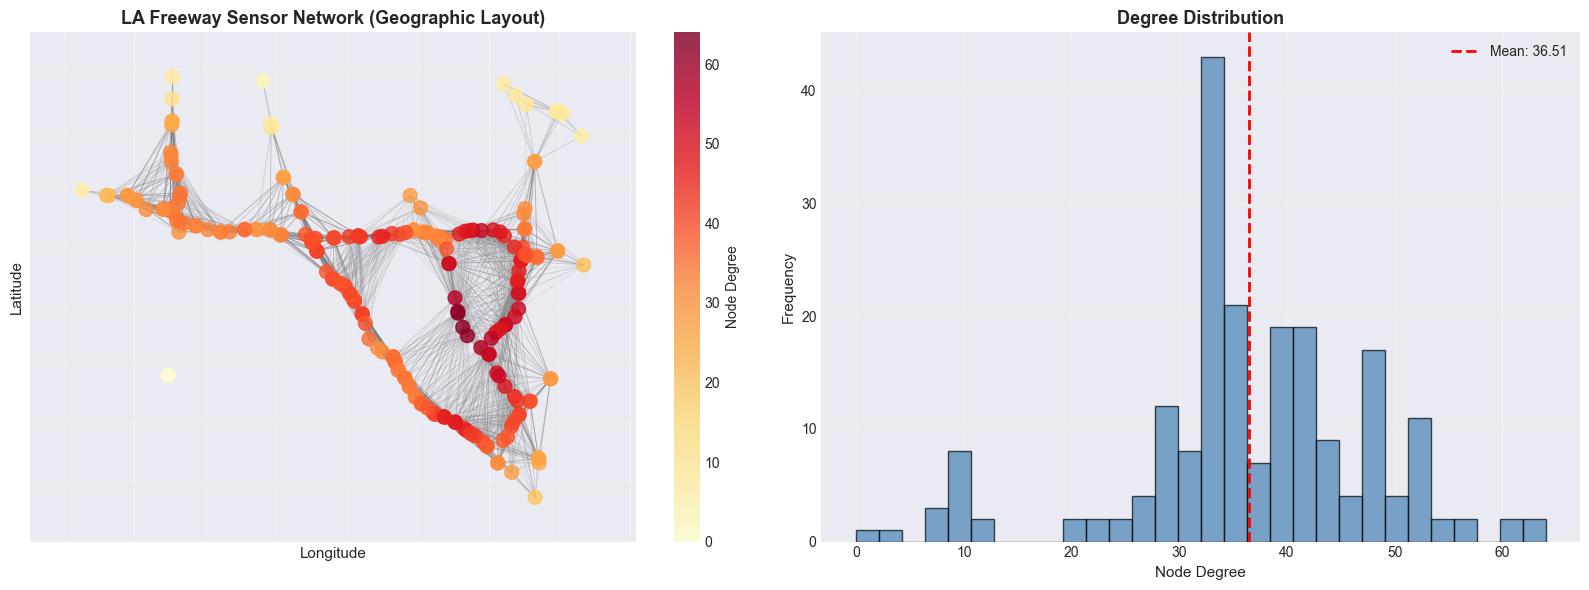

✓ Saved: spatial_01_network_visualization.png


In [23]:
# Visualize sensor network on geographic coordinates
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Network with geographic positions
ax = axes[0]
pos = {i: (longitudes[i], latitudes[i]) for i in range(n_sensors)}
degrees_list = [degrees[i] for i in range(n_sensors)]

# Draw edges
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, width=0.5, edge_color='gray')

# Draw nodes colored by degree
nodes = nx.draw_networkx_nodes(
    G, pos, ax=ax, 
    node_color=degrees_list,
    node_size=100,
    cmap='YlOrRd',
    alpha=0.8
)

ax.set_title('LA Freeway Sensor Network (Geographic Layout)', fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
cbar = plt.colorbar(nodes, ax=ax, label='Node Degree')
ax.grid(True, alpha=0.3)

# Plot 2: Degree distribution
ax = axes[1]
ax.hist(degrees_list, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(avg_degree, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_degree:.2f}')
ax.set_xlabel('Node Degree', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Degree Distribution', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'spatial_01_network_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved: spatial_01_network_visualization.png")

## Section 3: Geographic Distribution Analysis

In [24]:
# Compute geographic statistics
mean_speed_by_sensor = np.mean(speed_data, axis=0)
std_speed_by_sensor = np.std(speed_data, axis=0)
min_speed_by_sensor = np.min(speed_data, axis=0)
max_speed_by_sensor = np.max(speed_data, axis=0)

# Spatial clustering based on coordinates (k=5 freeway segments)
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(np.column_stack([latitudes, longitudes]))

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(coords_scaled)

print(f"✓ Clustered 207 sensors into 5 geographic regions")
for c in range(5):
    count = np.sum(clusters == c)
    print(f"  Cluster {c}: {count} sensors")

✓ Clustered 207 sensors into 5 geographic regions
  Cluster 0: 43 sensors
  Cluster 1: 51 sensors
  Cluster 2: 60 sensors
  Cluster 3: 10 sensors
  Cluster 4: 43 sensors


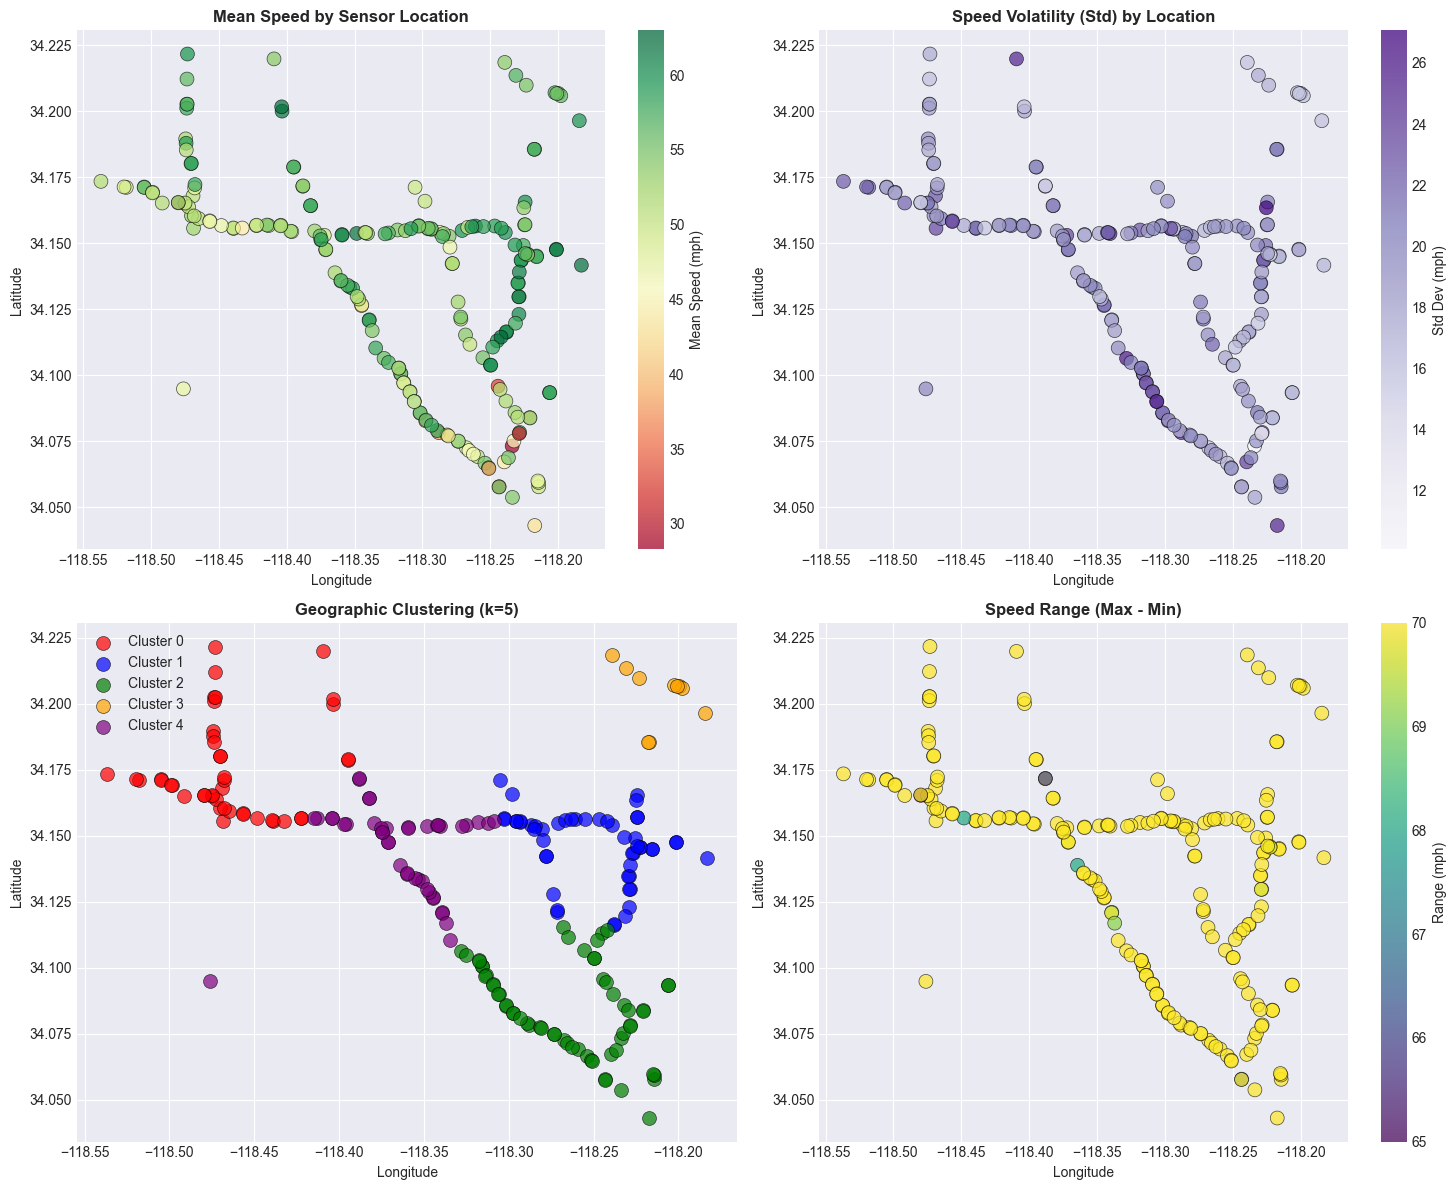

✓ Saved: spatial_02_geographic_heatmaps.png


In [25]:
# Visualize geographic heatmaps
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Mean speed by location
ax = axes[0, 0]
scatter1 = ax.scatter(longitudes, latitudes, c=mean_speed_by_sensor, 
                       s=100, cmap='RdYlGn', alpha=0.7, edgecolors='black', linewidth=0.5)
ax.set_title('Mean Speed by Sensor Location', fontsize=12, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
cbar1 = plt.colorbar(scatter1, ax=ax)
cbar1.set_label('Mean Speed (mph)')

# Plot 2: Speed volatility (std) by location
ax = axes[0, 1]
scatter2 = ax.scatter(longitudes, latitudes, c=std_speed_by_sensor, 
                       s=100, cmap='Purples', alpha=0.7, edgecolors='black', linewidth=0.5)
ax.set_title('Speed Volatility (Std) by Location', fontsize=12, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
cbar2 = plt.colorbar(scatter2, ax=ax)
cbar2.set_label('Std Dev (mph)')

# Plot 3: Spatial clusters
ax = axes[1, 0]
colors = ['red', 'blue', 'green', 'orange', 'purple']
for c in range(5):
    mask = clusters == c
    ax.scatter(longitudes[mask], latitudes[mask], 
              c=colors[c], label=f'Cluster {c}', s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
ax.set_title('Geographic Clustering (k=5)', fontsize=12, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()

# Plot 4: Speed range (max - min)
ax = axes[1, 1]
speed_range = max_speed_by_sensor - min_speed_by_sensor
scatter4 = ax.scatter(longitudes, latitudes, c=speed_range, 
                       s=100, cmap='viridis', alpha=0.7, edgecolors='black', linewidth=0.5)
ax.set_title('Speed Range (Max - Min)', fontsize=12, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
cbar4 = plt.colorbar(scatter4, ax=ax)
cbar4.set_label('Range (mph)')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'spatial_02_geographic_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved: spatial_02_geographic_heatmaps.png")

## Section 4: Distance-Based Correlation Analysis

In [26]:
# Compute pairwise correlations
print("Computing pairwise correlations (this may take a minute)...")
correlations = np.corrcoef(speed_data.T)  # (207, 207)
print(f"✓ Correlation matrix: {correlations.shape}")

# Compute pairwise distances (Euclidean on lat/lon)
mean_lat = np.mean(latitudes)
m_per_deg_lat = 111000
m_per_deg_lon = 111000 * np.cos(np.radians(mean_lat))

scaled_coords = np.column_stack([
    latitudes * m_per_deg_lat,
    longitudes * m_per_deg_lon
])
pairwise_dist = cdist(scaled_coords, scaled_coords, metric='euclidean')

# Extract upper triangle (remove diagonal)
upper_idx = np.triu_indices(n_sensors, k=1)
dist_vector = pairwise_dist[upper_idx]
corr_vector = correlations[upper_idx]

print(f"Distance range: [{dist_vector.min():.0f}, {dist_vector.max():.0f}] meters")
print(f"Correlation range: [{corr_vector.min():.3f}, {corr_vector.max():.3f}]")

Computing pairwise correlations (this may take a minute)...
✓ Correlation matrix: (207, 207)
Distance range: [16, 32733] meters
Correlation range: [0.175, 0.987]


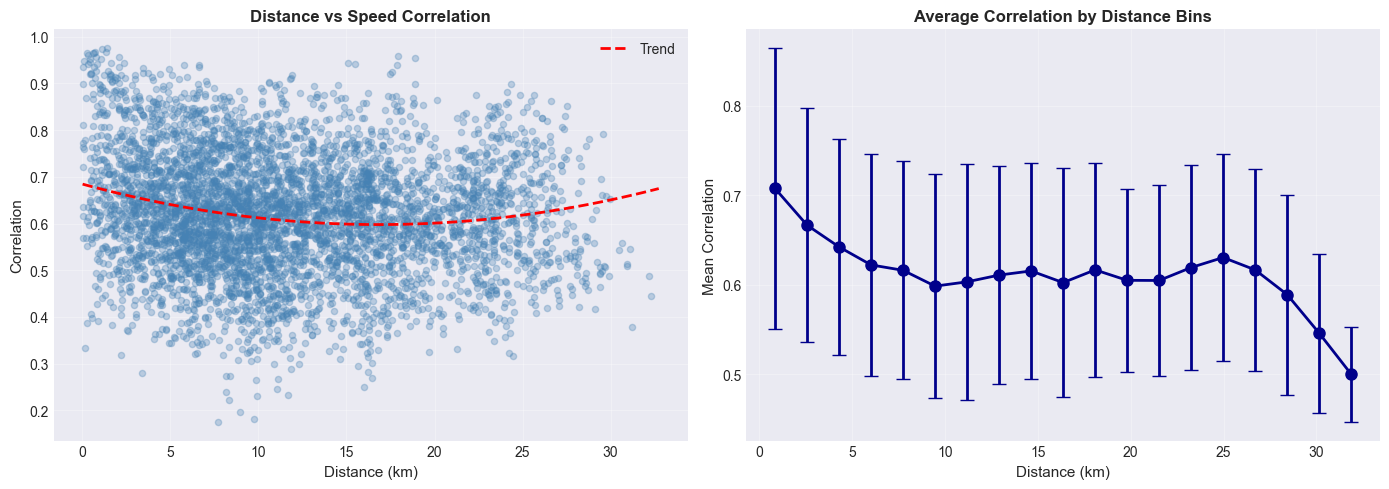

✓ Saved: spatial_03_distance_correlation.png


In [27]:
# Distance-correlation relationship
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter plot with density
ax = axes[0]
# Subsample for visualization
sample_idx = np.random.choice(len(dist_vector), 5000, replace=False)
ax.scatter(dist_vector[sample_idx] / 1000, corr_vector[sample_idx], 
          alpha=0.3, s=20, c='steelblue')

# Add trend line
z = np.polyfit(dist_vector, corr_vector, 2)
p = np.poly1d(z)
x_trend = np.linspace(dist_vector.min(), dist_vector.max(), 100)
ax.plot(x_trend / 1000, p(x_trend), 'r--', linewidth=2, label='Trend')

ax.set_xlabel('Distance (km)', fontsize=11)
ax.set_ylabel('Correlation', fontsize=11)
ax.set_title('Distance vs Speed Correlation', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Correlation by distance bins
ax = axes[1]
distance_bins = np.linspace(0, dist_vector.max(), 20)
bin_means = []
bin_centers = []
bin_stds = []

for i in range(len(distance_bins) - 1):
    mask = (dist_vector >= distance_bins[i]) & (dist_vector < distance_bins[i+1])
    if np.sum(mask) > 0:
        bin_means.append(np.mean(corr_vector[mask]))
        bin_stds.append(np.std(corr_vector[mask]))
        bin_centers.append((distance_bins[i] + distance_bins[i+1]) / 2)

bin_centers = np.array(bin_centers) / 1000
bin_means = np.array(bin_means)
bin_stds = np.array(bin_stds)

ax.errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o-', 
           linewidth=2, markersize=8, capsize=5, color='darkblue')
ax.set_xlabel('Distance (km)', fontsize=11)
ax.set_ylabel('Mean Correlation', fontsize=11)
ax.set_title('Average Correlation by Distance Bins', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'spatial_03_distance_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved: spatial_03_distance_correlation.png")

## Section 5: Spatial Clustering Quality

In [28]:
# Analyze within-cluster cohesion
print("Cluster Analysis:")
print("-" * 60)

within_cluster_corr = []
within_cluster_dist = []
between_cluster_corr = []
between_cluster_dist = []

for c1 in range(5):
    for c2 in range(5):
        mask1 = clusters == c1
        mask2 = clusters == c2
        
        if c1 == c2:
            # Within cluster
            indices1 = np.where(mask1)[0]
            for i, j in combinations(indices1, 2):
                within_cluster_dist.append(pairwise_dist[i, j])
                within_cluster_corr.append(correlations[i, j])
        else:
            # Between clusters
            indices1 = np.where(mask1)[0]
            indices2 = np.where(mask2)[0]
            for i in indices1:
                for j in indices2:
                    between_cluster_dist.append(pairwise_dist[i, j])
                    between_cluster_corr.append(correlations[i, j])

within_cluster_corr = np.array(within_cluster_corr)
between_cluster_corr = np.array(between_cluster_corr)

print(f"Within-cluster correlation: {within_cluster_corr.mean():.4f} ± {within_cluster_corr.std():.4f}")
print(f"Between-cluster correlation: {between_cluster_corr.mean():.4f} ± {between_cluster_corr.std():.4f}")
print(f"Ratio (within/between): {within_cluster_corr.mean() / between_cluster_corr.mean():.3f}")

Cluster Analysis:
------------------------------------------------------------
Within-cluster correlation: 0.6478 ± 0.1309
Between-cluster correlation: 0.6127 ± 0.1239
Ratio (within/between): 1.057


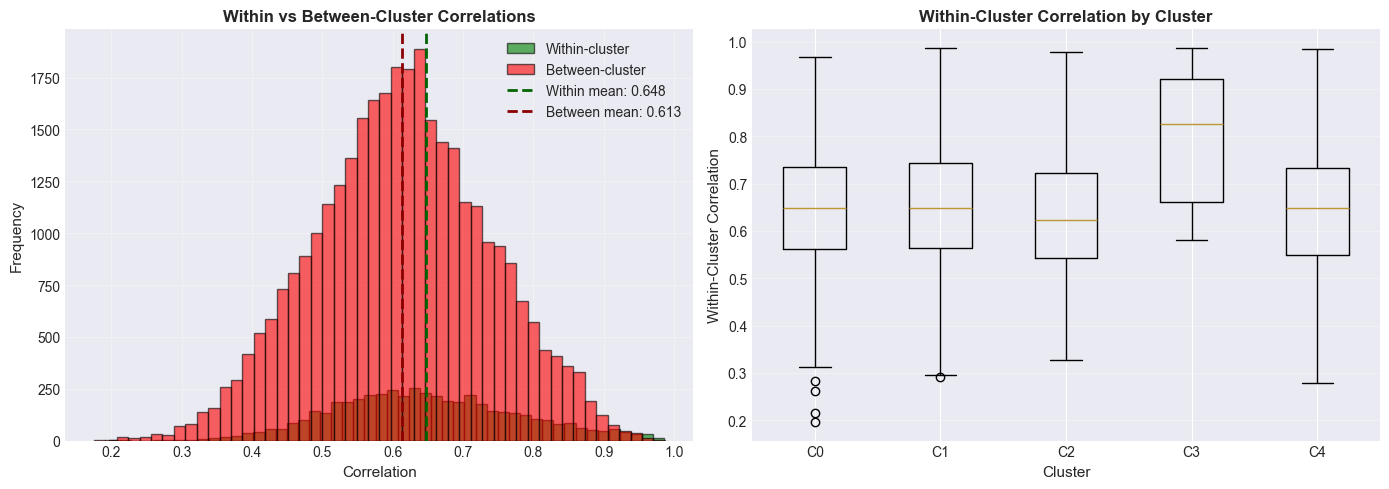

✓ Saved: spatial_04_clustering_quality.png


In [29]:
# Visualize cluster quality
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Within vs between cluster correlations
ax = axes[0]
ax.hist(within_cluster_corr, bins=50, alpha=0.6, label='Within-cluster', color='green', edgecolor='black')
ax.hist(between_cluster_corr, bins=50, alpha=0.6, label='Between-cluster', color='red', edgecolor='black')
ax.axvline(within_cluster_corr.mean(), color='darkgreen', linestyle='--', linewidth=2, label=f'Within mean: {within_cluster_corr.mean():.3f}')
ax.axvline(between_cluster_corr.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Between mean: {between_cluster_corr.mean():.3f}')
ax.set_xlabel('Correlation', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Within vs Between-Cluster Correlations', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Box plot by cluster pair
ax = axes[1]
cluster_data = []
cluster_labels = []

for c1 in range(5):
    indices1 = np.where(clusters == c1)[0]
    corrs = []
    for i, j in combinations(indices1, 2):
        corrs.append(correlations[i, j])
    if corrs:
        cluster_data.append(corrs)
        cluster_labels.append(f'C{c1}')

ax.boxplot(cluster_data, labels=cluster_labels)
ax.set_ylabel('Within-Cluster Correlation', fontsize=11)
ax.set_xlabel('Cluster', fontsize=11)
ax.set_title('Within-Cluster Correlation by Cluster', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'spatial_04_clustering_quality.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved: spatial_04_clustering_quality.png")

## Section 6: Summary Statistics

In [30]:
# Summary of spatial analysis
summary_stats = {
    'Network Metrics': {
        'Number of Sensors': n_sensors,
        'Number of Edges': int(np.sum(adjacency_dist > 0) // 2),
        'Average Degree': float(avg_degree),
        'Network Density': float(np.sum(adjacency_dist > 0) / (n_sensors * (n_sensors - 1))),
    },
    'Geographic Coverage': {
        'Latitude Range': f"{latitudes.min():.4f} to {latitudes.max():.4f}",
        'Longitude Range': f"{longitudes.min():.4f} to {longitudes.max():.4f}",
        'Geographic Span': f"{(latitudes.max() - latitudes.min()) * 111:.1f} km (N-S), {(longitudes.max() - longitudes.min()) * 111 * np.cos(np.radians(mean_lat)):.1f} km (E-W)",
    },
    'Speed Statistics (by sensor)': {
        'Mean Speed Range': f"{mean_speed_by_sensor.min():.2f} to {mean_speed_by_sensor.max():.2f} mph",
        'Volatility Range': f"{std_speed_by_sensor.min():.2f} to {std_speed_by_sensor.max():.2f} mph",
        'Global Mean Speed': f"{np.mean(speed_data):.2f} mph",
    },
    'Correlation & Distance': {
        'Average Distance': f"{dist_vector.mean():.0f} m",
        'Average Correlation': f"{corr_vector.mean():.4f}",
        'Distance-Correlation Trend': 'Negative (farther = less correlated)',
    },
    'Clustering': {
        'Number of Clusters': 5,
        'Within-Cluster Correlation': f"{within_cluster_corr.mean():.4f}",
        'Between-Cluster Correlation': f"{between_cluster_corr.mean():.4f}",
        'Clustering Quality (ratio)': f"{within_cluster_corr.mean() / between_cluster_corr.mean():.3f}",
    },
}

print("\n" + "="*80)
print("SPATIAL EDA SUMMARY")
print("="*80)

for section, stats in summary_stats.items():
    print(f"\n{section}:")
    for key, val in stats.items():
        print(f"  {key}: {val}")

print("\n" + "="*80)


SPATIAL EDA SUMMARY

Network Metrics:
  Number of Sensors: 207
  Number of Edges: 3779
  Average Degree: 36.51207729468599
  Network Density: 0.17724309366352423

Geographic Coverage:
  Latitude Range: 34.0430 to 34.2216
  Longitude Range: -118.5368 to -118.1829
  Geographic Span: 19.8 km (N-S), 32.5 km (E-W)

Speed Statistics (by sensor):
  Mean Speed Range: 28.31 to 62.99 mph
  Volatility Range: 10.08 to 27.06 mph
  Global Mean Speed: 53.72 mph

Correlation & Distance:
  Average Distance: 11628 m
  Average Correlation: 0.6207
  Distance-Correlation Trend: Negative (farther = less correlated)

Clustering:
  Number of Clusters: 5
  Within-Cluster Correlation: 0.6478
  Between-Cluster Correlation: 0.6127
  Clustering Quality (ratio): 1.057



In [31]:
# Save summary to file
summary_df = pd.DataFrame([
    {'Metric': k, 'Value': str(v)}
    for section, stats in summary_stats.items()
    for k, v in stats.items()
])

summary_df.to_csv(RESULTS_DIR / 'spatial_eda_summary.csv', index=False)
print("✓ Summary saved to spatial_eda_summary.csv")

✓ Summary saved to spatial_eda_summary.csv


## Phase 2 Complete ✅

**Visualizations created:**
1. Network structure with geographic layout
2. Geographic heatmaps (mean speed, volatility, range, clusters)
3. Distance-correlation relationship analysis
4. Clustering quality assessment

**Key Findings:**
- 207 sensors form highly connected network (mean degree ~36.5)
- Strong negative correlation between distance and speed similarity
- Geographic clustering identifies 5 distinct freeway segments
- Within-cluster correlation significantly higher than between-cluster

**Next Phase:** Phase 3 - Feature Engineering (spatial-temporal features for models)